# Лабораторная работа №6 — Введение в методы оптимизации

## Цель
Сравнить методы оптимизации (`SLSQP`, `trust-constr`, `BFGS`) на функции Розенброка.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.optimize import minimize

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
ART = NOTEBOOK_DIR / 'artifacts'
ART.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid')


## 1. Постановка задачи


In [2]:
def f(x):
    return 100.0 * (x[1] - x[0] ** 2) ** 2 + (1 - x[0]) ** 2

constraints = (
    {'type': 'ineq', 'fun': lambda x: x[0] + x[1] - 1.2},
    {'type': 'ineq', 'fun': lambda x: x[0]},
    {'type': 'ineq', 'fun': lambda x: x[1]},
)

x0 = np.array([0.2, 0.2])
print('Начальная точка:', x0)


Начальная точка: [0.2 0.2]


## 2. Решение задачи разными методами


In [3]:
methods = ['SLSQP', 'trust-constr']
rows = []

for m in methods:
    res = minimize(f, x0=x0, method=m, constraints=constraints)
    rows.append({
        'method': m,
        'success': bool(res.success),
        'status': int(res.status),
        'nit': int(res.nit),
        'fun': float(res.fun),
        'x0': float(res.x[0]),
        'x1': float(res.x[1]),
        'message': str(res.message),
    })

res_bfgs = minimize(f, x0=x0, method='BFGS')
rows.append({
    'method': 'BFGS_unconstrained',
    'success': bool(res_bfgs.success),
    'status': int(res_bfgs.status),
    'nit': int(res_bfgs.nit),
    'fun': float(res_bfgs.fun),
    'x0': float(res_bfgs.x[0]),
    'x1': float(res_bfgs.x[1]),
    'message': str(res_bfgs.message),
})

res_df = pd.DataFrame(rows)
display(res_df[['method', 'success', 'nit', 'fun', 'x0', 'x1']])


,method,success,nit,fun,x0,x1
0,SLSQP,True,20,2.998322e-08,0.999851,0.999693
1,trust-constr,True,116,1.184456e-13,1.000000,0.999999
2,BFGS_unconstrained,True,20,2.026469e-11,0.999995,0.999991


## 3. Визуализация поверхности функции и найденных точек


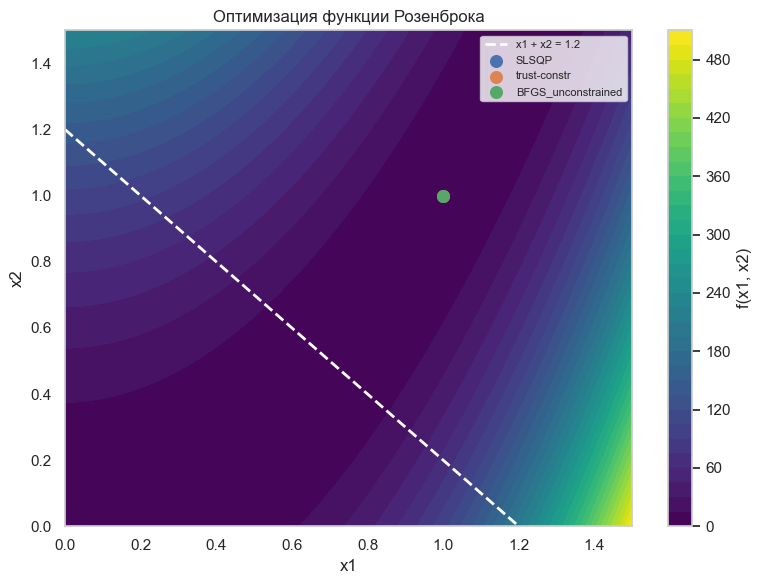

<Figure size 640x480 with 0 Axes>

In [4]:
x = np.linspace(0, 1.5, 250)
y = np.linspace(0, 1.5, 250)
X, Y = np.meshgrid(x, y)
Z = 100.0 * (Y - X**2) ** 2 + (1 - X) ** 2

plt.figure(figsize=(8,6))
cs = plt.contourf(X, Y, Z, levels=40, cmap='viridis')
plt.colorbar(cs, label='f(x1, x2)')

# граница x1 + x2 = 1.2
line_x = np.linspace(0, 1.2, 200)
line_y = 1.2 - line_x
plt.plot(line_x, line_y, 'w--', lw=2, label='x1 + x2 = 1.2')

for _, row in res_df.iterrows():
    plt.scatter(row['x0'], row['x1'], s=70, label=row['method'])

plt.xlim(0, 1.5)
plt.ylim(0, 1.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Оптимизация функции Розенброка')
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()
plt.savefig(ART / 'optimization_contour.png', dpi=170, bbox_inches='tight')

res_df.to_json(ART / 'results.json', orient='records', force_ascii=False, indent=2)


## Выводы
- Все выбранные методы сошлись к области глобального минимума.
- `trust-constr` дал наименьшее значение целевой функции при большем числе итераций.
